In [137]:
##### IMPORTS

import os
os.environ['picaso_refdata'] = r'C:\Users\Alex\Desktop\Picaso\picaso\reference' # THIS MUST GO BEFORE YOUR IMPORT STATEMENT
os.environ['PYSYN_CDBS'] = r'C:\Users\Alex\Desktop\Picaso\grp\redcat\trds' # This is for the stellar data discussed below.

# General
import pickle
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from scipy.interpolate import RegularGridInterpolator

# Picaso and Virga
from picaso import justdoit as jdi

In [138]:
##### CONFIGURATIONS

# Directories
sonor_path  = r'C:\Users\Alex\Desktop\Picaso\data\bob' # Sonora db
# sonor_path  = '/groups/tkaralidi/pbraunschweig/training_set/profiles/'
opaci_path  = None # Opacity db
# opcai_path  = '/groups/tkaralidi/opacity_500k_for_R5000_egpoutput.db'
pickl_path  = r"C:\Users\Alex\Desktop\Picaso\NN_project\cloudy_spectra_code\bobcat_to_diamondback.pickle"
# pickl_path  = "home/al864695/pickle"

In [139]:
##### PICKLE TRIAL AND ERROR

# The pickle is a numpy array of shape [301, 41, 5, 91]
# From Theodora code
# 301 corresponds to teff from [900, 2400] at 5 K steps
# 41 corresponds to logg from [3.50, 5.50] at 0.05 steps
# 5 corresponds to fsed from [1, 2, 3, 4, 8]
# 91 corresponds to 91 layers
# Each entry is a temp? correction factor for that layer

# Load and define axes
corrp  = pickle.load(open(pickl_path, "rb"))      # shape (301, 41, 5, 91)
taxis  = np.arange(900.0, 2405.0, 5.0)            # 900..2400 (step 5)
gaxis  = np.arange(3.50, 5.55, 0.05)              # 3.50..5.50 (step 0.05)
faxis  = np.array([1.0, 2.0, 3.0, 4.0, 8.0])      # fsed axis

# How does this handle values outside of this range?
# Only fsed is not interpolated so that can be reference axis

def inject_corr(bd, Teff, logg, fsed, clip_oob=True):
    """
    Apply Diamondback/Bobcat TP correction to PICASO inputs.
    Multiplies the current temperature profile by a correction factor
    interpolated over (Teff, logg) at nearest fsed.
    """
    # Choose the nearest fsed index not fsed itself
    # If fsed = 3
    # np.abs(faxis - fsed) = [2, 1, 0, 1, 5]
    # np.argmin() returns index of smallest value, 0, which is the 3
    # int() gives this clean index
    fi = int(np.argmin(np.abs(faxis - float(fsed))))

    # What is Teff or logg are out this grid?
    # For now, just attach the closest correction value
    # astrodata - np.clip(x, min, max), if x is within bounds GOOD
    # if x out of bounds, it returns either the min or max
    # same with g

    # Clip Teff/logg to grid so out of bound values still gets a correction
    Teff_in = float(np.clip(Teff, taxis[0], taxis[-1]))
    logg_in = float(np.clip(logg, gaxis[0], gaxis[-1]))

    # Interpolate over Teff and log g at that fsed
    # Build rgi over (Teff and logg) with (Teff, logg, 91)
    rgi = RegularGridInterpolator((taxis, gaxis), corrp[:, :, fi, :])
    
    # Correction value
    corr = rgi((Teff_in, logg_in)).ravel()

    # Correcting PT profile PICASO
    prof = bd.inputs["atmosphere"]["profile"]
    T    = np.asarray(prof["temperature"], float)
    prof["temperature"] = (T * corr).tolist()

In [140]:
##### TEST TP PROFILE NEW AND OLD

# Parameters
wav_range = [0.3, 5.0] # microns
Teff_s    = 1500.0 # K
logg_s    = 3.49   # cgs
fsed_s    = 2.0
grav_s    = (10**logg_s) * 1e-2   # m s^-2

# Calculate
opa       = jdi.opannection(wav_range, opaci_path)
bd        = jdi.inputs(calculation="browndwarf")
bd.phase_angle(0)
bd.gravity(grav_s, gravity_unit=u.Unit('m s^-2'))
bd.sonora(sonor_path, Teff_s)

# TP PROFILE BEFORE
prof   = bd.inputs['atmosphere']['profile']
T_before = np.array(prof["temperature"], dtype=float)

# APPLY CORRECTION
_ = inject_corr(bd, Teff_s, logg_s, fsed_s)
T_after = np.array(prof["temperature"], dtype=float)

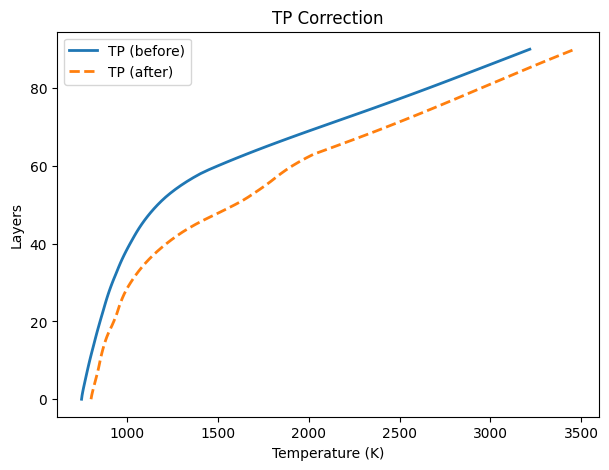

In [141]:
##### PLOT

layers = T_before.size
y = np.arange(layers)

plt.figure(figsize=(7, 5))
plt.plot(T_before, y, label="TP (before)", linewidth=2)
plt.plot(T_after,  y, label="TP (after)",  linewidth=2, linestyle="--")
plt.xlabel("Temperature (K)")
plt.ylabel("Layers")
plt.title("TP Correction")
plt.legend()
plt.show()

In [142]:
print(T_before)

[ 749.27  752.19  756.11  760.51  765.21  769.91  774.62  779.42  784.27
  789.25  794.39  799.7   805.16  810.77  816.38  821.88  827.41  833.1
  838.97  845.    851.09  857.26  863.59  869.86  876.01  882.3   888.88
  895.8   903.1   910.82  918.95  927.47  936.39  945.13  953.78  962.9
  972.55  982.74  993.46 1004.66 1016.29 1028.26 1040.29 1052.83 1066.21
 1080.52 1095.82 1112.18 1129.62 1148.28 1168.25 1189.7  1213.04 1238.73
 1266.69 1296.99 1329.76 1365.26 1403.78 1449.09 1498.89 1550.01 1602.48
 1656.25 1711.22 1767.41 1824.86 1883.15 1942.22 2002.12 2062.82 2123.44
 2184.08 2244.85 2305.76 2365.93 2425.47 2484.5  2543.14 2601.27 2658.82
 2715.83 2772.32 2828.32 2883.99 2939.69 2995.35 3050.95 3106.46 3161.87
 3217.18]
